In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from ariel_pred.dataset import DataLoaderAndCalibrator
from ariel_pred.preprocessing import SGSmoothing
from ariel_pred.plots import plot_white_curve
from ariel_pred.transit import FunctionFittingBasedPhaseDetector
from ariel_pred.models import TransitMultiplicationFactorFinder
from ariel_pred.features import WavelengthsGroupsMultiplierFinder
from ariel_pred.metrics import score, score_single_row
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import random
from scipy.optimize import minimize
from tqdm.auto import tqdm
import pandas as pd

In [4]:
data_loader = DataLoaderAndCalibrator(
    data_path=Path("../data/raw"),
    output_path=Path("../data/calibrated/full"),
    force_recalibration=False,
    cut_airs_channels=True,
    binning=4,
    n_jobs=4
)
train_data, train_labels = data_loader.load_all_train_data()
train_data.shape, train_labels.shape

Loading calibrated train data...


((1100, 1406, 283), (1100, 283))

In [5]:
features_extractor = WavelengthsGroupsMultiplierFinder()

features, transit_locations = features_extractor.extract_features(train_data, return_transit_locations=True)
features.shape, transit_locations.shape

  0%|          | 0/1100 [00:00<?, ?it/s]

100%|██████████| 1100/1100 [03:22<00:00,  5.45it/s]


((1100, 283), (1100, 4))

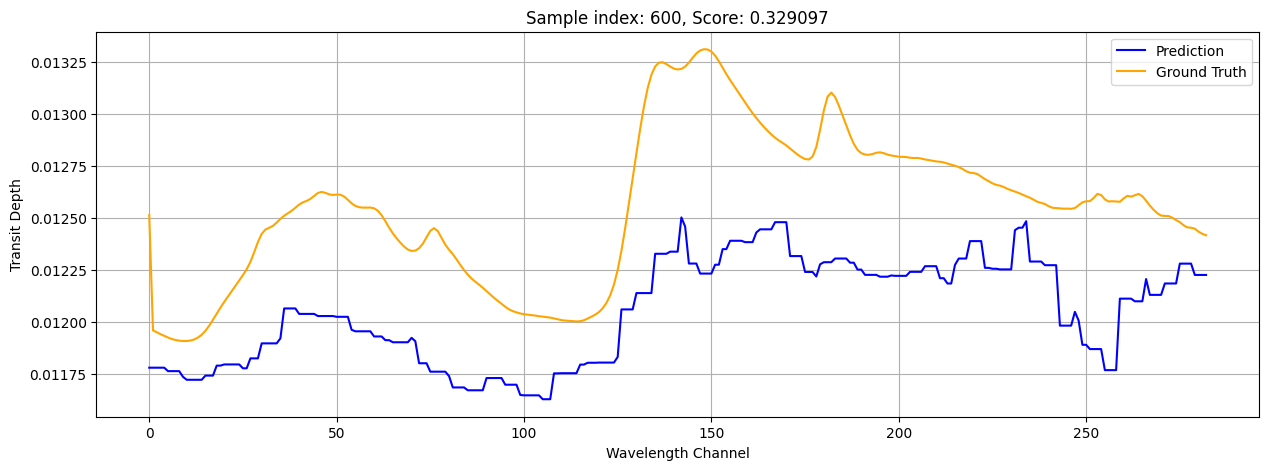

In [6]:
random_index = random.randint(0, features.shape[0] - 1)
sigma = 0.000715
plt.figure(figsize=(15, 5))
plt.plot(0.945 * features[random_index], label="Prediction", color="blue")
plt.plot(train_labels[random_index], label="Ground Truth", color="orange")
plt.legend()
gll = score_single_row(
    submission=np.concatenate((0.945 * features[random_index], np.ones_like(features[random_index]) * sigma)), 
    solution=train_labels[random_index],
    naive_mean=train_labels.mean(),
    naive_sigma=train_labels.std()
)
plt.title(f"Sample index: {random_index}, Score: {gll:.6f}")
plt.xlabel("Wavelength Channel")
plt.ylabel("Transit Depth")
plt.grid()
plt.show()

In [7]:
all_gll = np.array([
    score_single_row(
        submission=np.concatenate((0.945 * features[i], np.ones_like(features[i]) * sigma)), 
        solution=train_labels[i],
        naive_mean=train_labels.mean(),
        naive_sigma=train_labels.std()
    )
    for i in range(features.shape[0])
])

In [8]:
all_gll.mean()

np.float64(0.35785245023945234)

In [9]:
df = pd.DataFrame(
    np.concatenate(
        (
            np.arange(features.shape[0])[:, np.newaxis],
            features,
            transit_locations,
            all_gll[:, np.newaxis]
        ),
        axis=1
    ),
    columns=["index"] + [f"wl_{i}" for i in range(features.shape[1])] + ['t0', 't1', 't2', 't3'] + ["gll"]
)

In [10]:
df.head()

,index,wl_0,wl_1,wl_2,wl_3,wl_4,wl_5,wl_6,wl_7,wl_8,...,wl_278,wl_279,wl_280,wl_281,wl_282,t0,t1,t2,t3,gll
0,0.0,0.019662,0.019662,0.019662,0.019662,0.019662,0.019635,0.019635,0.019635,0.019635,...,0.018911,0.018826,0.018826,0.018826,0.018826,443.0,539.0,968.0,1068.0,0.364583
1,1.0,0.006100,0.006100,0.006100,0.006100,0.006100,0.006094,0.006094,0.006094,0.006094,...,0.006404,0.006598,0.006598,0.006598,0.006598,148.0,252.0,1148.0,1248.0,0.361780
2,2.0,0.051528,0.051528,0.051528,0.051528,0.051528,0.051517,0.051517,0.051517,0.051517,...,0.050600,0.050846,0.050846,0.050846,0.050846,343.0,466.0,817.0,938.0,0.194188
3,3.0,0.015748,0.015748,0.015748,0.015748,0.015748,0.015780,0.015780,0.015780,0.015780,...,0.015582,0.015540,0.015540,0.015540,0.015540,351.0,486.0,917.0,1051.0,0.311753
4,4.0,0.015637,0.015637,0.015637,0.015637,0.015637,0.015646,0.015646,0.015646,0.015646,...,0.014908,0.015025,0.015025,0.015025,0.015025,262.0,372.0,1001.0,1110.0,0.365745


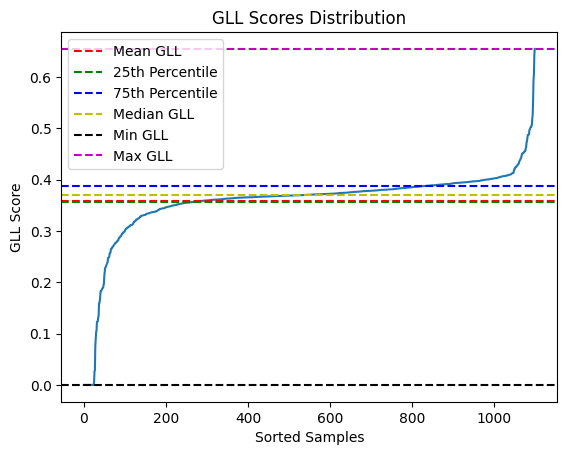

In [11]:
plt.plot(df['gll'].sort_values().values)
plt.axhline(y=all_gll.mean(), color='r', linestyle='--', label='Mean GLL')
plt.axhline(y=np.percentile(all_gll, 25), color='g', linestyle='--', label='25th Percentile')
plt.axhline(y=np.percentile(all_gll, 75), color='b', linestyle='--', label='75th Percentile')
plt.axhline(y=df['gll'].median(), color='y', linestyle='--', label='Median GLL')
plt.axhline(y=df['gll'].min(), color='k', linestyle='--', label='Min GLL')
plt.axhline(y=df['gll'].max(), color='m', linestyle='--', label='Max GLL')
plt.title("GLL Scores Distribution")
plt.xlabel("Sorted Samples")
plt.ylabel("GLL Score")
plt.legend()
plt.show()

In [12]:
np.median(all_gll), all_gll.mean()

(np.float64(0.3706863033989113), np.float64(0.35785245023945234))

In [13]:
(df['gll'] <= 0.20).sum() / df.shape[0]

np.float64(0.045454545454545456)

In [14]:
smoother = SGSmoothing(window_size=150, poly_order=2)


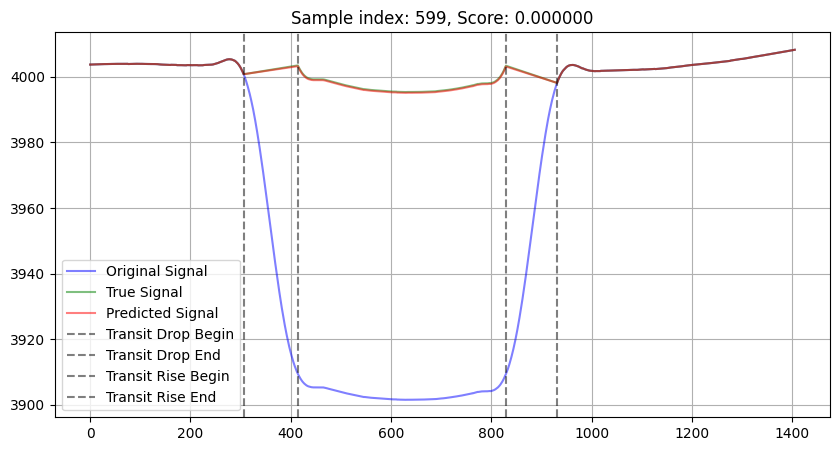

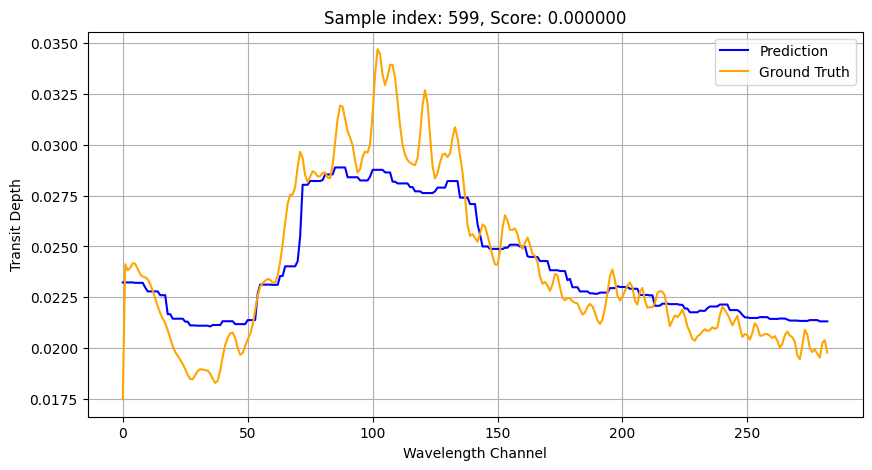

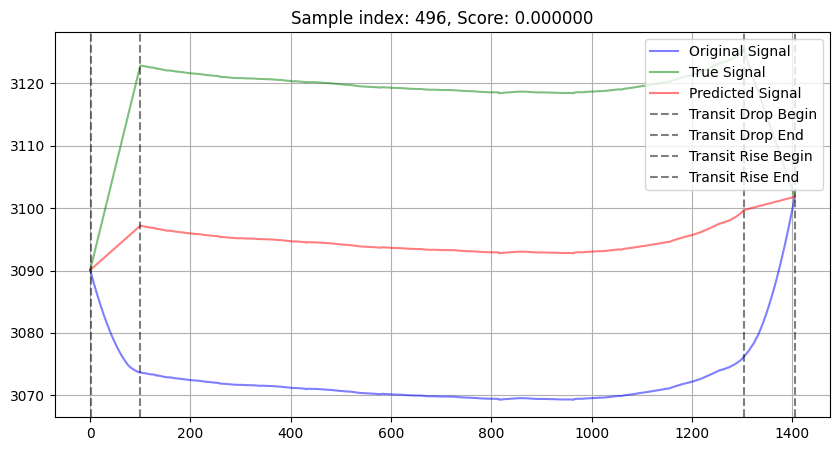

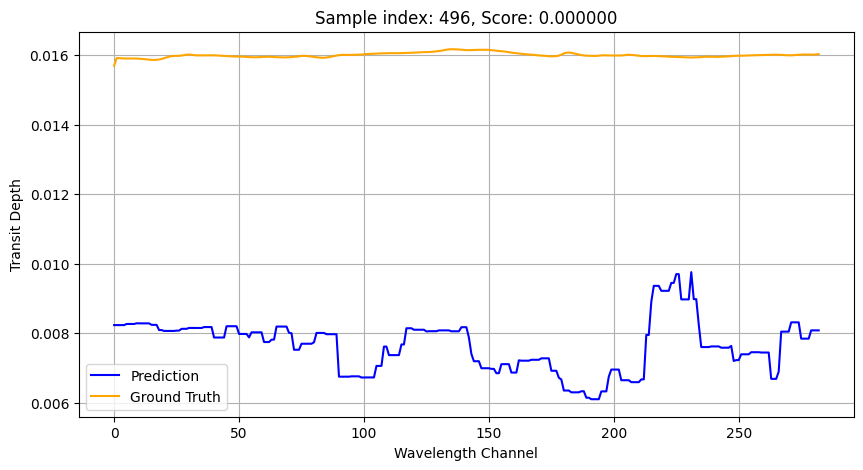

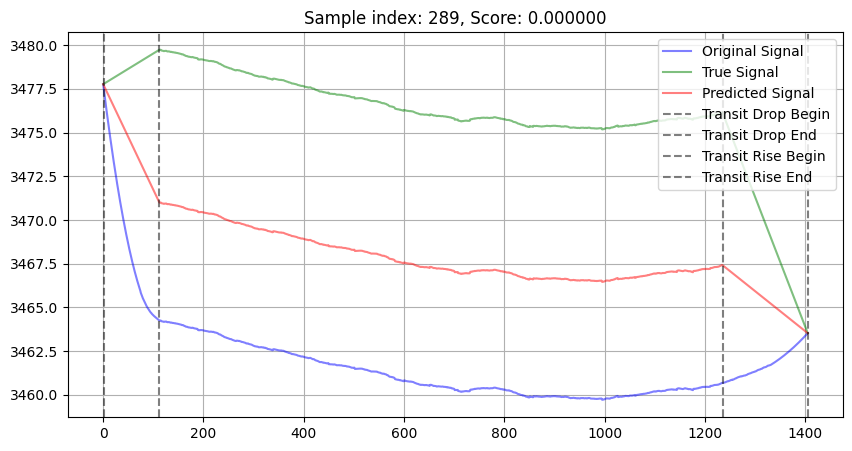

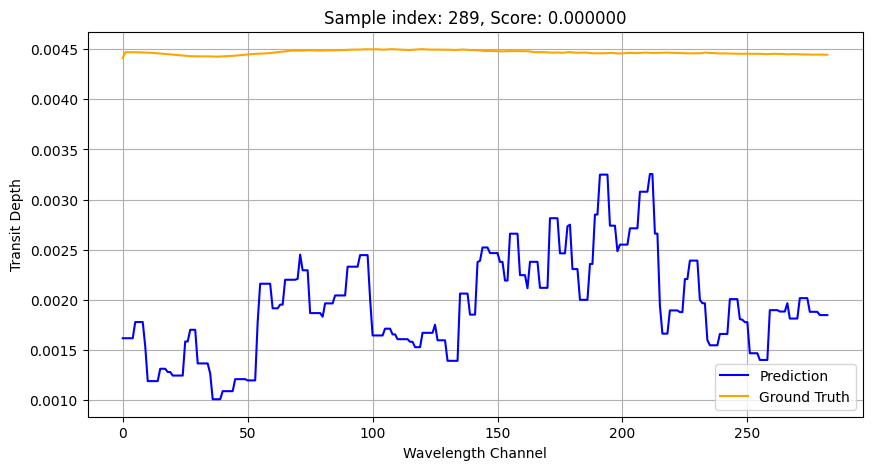

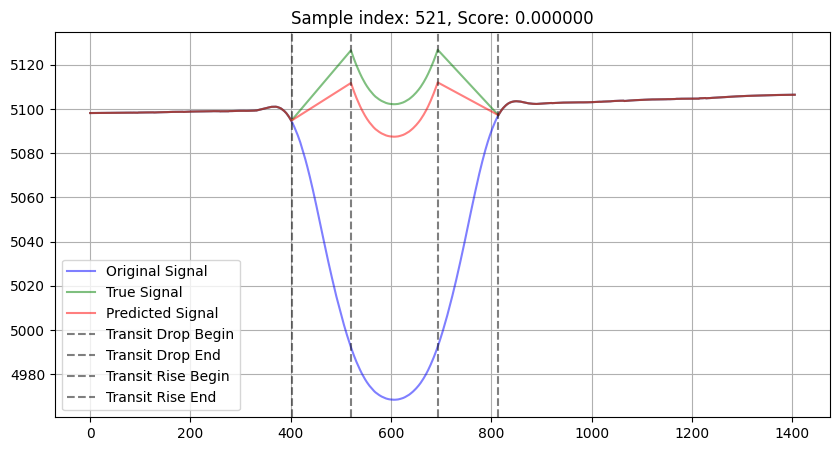

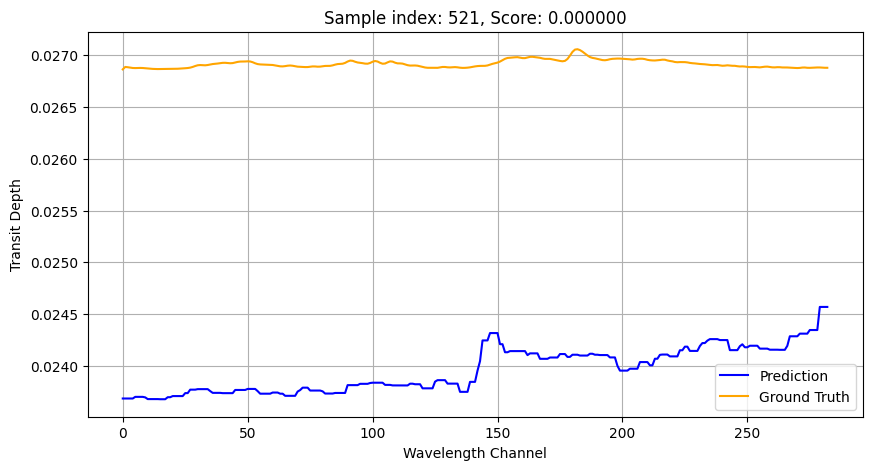

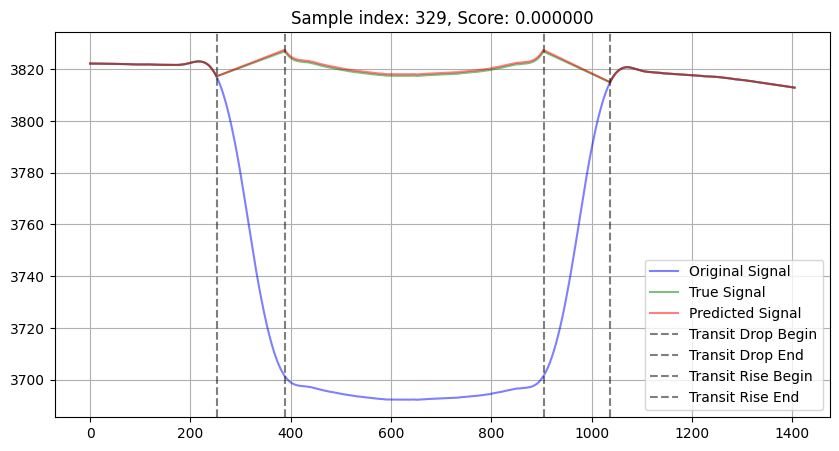

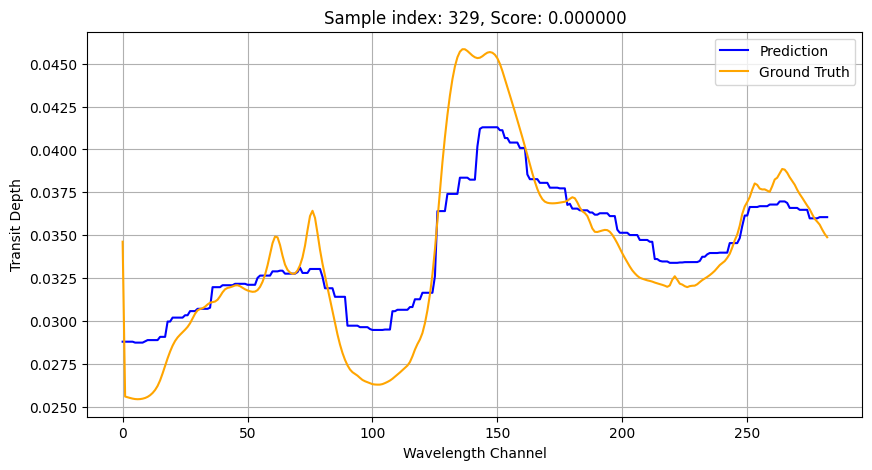

In [15]:
worst_indices = df.sort_values(by='gll')[:5]['index'].values

for i, idx in enumerate(worst_indices):
    idx = int(idx)
    signal = smoother.smooth(train_data[idx].mean(axis=1))
    t0, t1, t2, t3 = map(int, df.loc[df['index'] == idx, ['t0', 't1', 't2', 't3']].values[0])
    predicted = 0.945 * features[idx]
    label = train_labels[idx]
    
    predicted_signal = np.concatenate([
        signal[:t0],
        signal[t1:t2] * (1.0+predicted.mean()),
        signal[t3:]
    ])

    true_signal = np.concatenate([
        signal[:t0],
        signal[t1:t2] * (1.0+label.mean()),
        signal[t3:]
    ])
    # Plot light curve
    plt.figure(figsize=(10, 5))
    plt.title(f"Sample index: {idx}, Score: {df.loc[df['index'] == idx, 'gll'].values[0]:.6f}")
    plt.plot(signal, label="Original Signal", alpha=0.5, color="blue")
    x = np.concatenate([
        np.arange(t0),
        np.arange(t1, t2),
        np.arange(t3, len(signal))
    ])
    plt.plot(x, true_signal, label="True Signal", alpha=0.5, color="green")
    plt.plot(x, predicted_signal, label="Predicted Signal", alpha=0.5, color="red")
    plt.axvline(t0, color="black", linestyle="--", alpha=0.5, label="Transit Drop Begin")
    plt.axvline(t1, color="black", linestyle="--", alpha=0.5, label="Transit Drop End")
    plt.axvline(t2, color="black", linestyle="--", alpha=0.5, label="Transit Rise Begin")
    plt.axvline(t3, color="black", linestyle="--", alpha=0.5, label="Transit Rise End")
    plt.legend()
    plt.grid()
    plt.show()
    
    # Plot predections vs labels
    plt.figure(figsize=(10, 5))
    plt.plot(0.945 * features[idx], label="Prediction", color="blue")
    plt.plot(train_labels[idx], label="Ground Truth", color="orange")
    plt.title(f"Sample index: {idx}, Score: {df.loc[df['index'] == idx, 'gll'].values[0]:.6f}")
    plt.xlabel("Wavelength Channel")
    plt.ylabel("Transit Depth")
    plt.legend()
    plt.grid()
    plt.show()

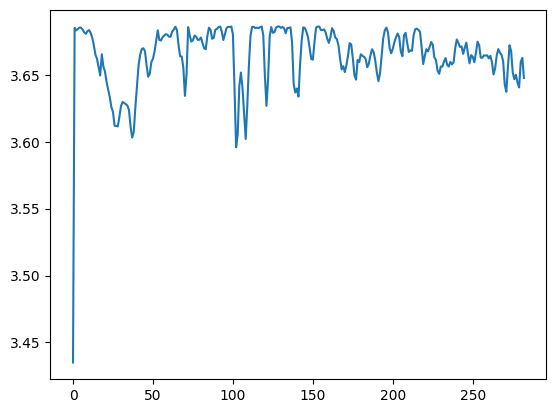

In [16]:
plt.plot((-0.5*((features[599] - train_labels[599])**2 / 0.01**2 + np.log(2 * np.pi * 0.01**2))))

In [17]:
def calc_gll(y, mu, sigma):
    return -0.5*((y - mu)**2 / sigma**2 + np.log(2 * np.pi * sigma**2))

In [18]:
# Add in the dataframe gll per channel columns
# Predections are in column wl_0 to wl_(n-1)
# Labels are in train_labels
for i in range(features.shape[1]):
    df[f'gll_{i}'] = calc_gll(train_labels[:, i], 0.945 * features[:, i], sigma)

/var/folders/gr/hcjptshj2_l1mqdwnfv3krh40000gn/T/ipykernel_45062/2935947307.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'gll_{i}'] = calc_gll(train_labels[:, i], 0.945 * features[:, i], sigma)
/var/folders/gr/hcjptshj2_l1mqdwnfv3krh40000gn/T/ipykernel_45062/2935947307.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'gll_{i}'] = calc_gll(train_labels[:, i], 0.945 * features[:, i], sigma)
/var/folders/gr/hcjptshj2_l1mqdwnfv3krh40000gn/T/ipykernel_45062/2935947307.py:5: PerformanceWarning: DataFrame is highly fr

In [19]:
df.to_csv("./data.csv")

In [20]:
df.head()

,index,wl_0,wl_1,wl_2,wl_3,wl_4,wl_5,wl_6,wl_7,wl_8,...,gll_273,gll_274,gll_275,gll_276,gll_277,gll_278,gll_279,gll_280,gll_281,gll_282
0,0.0,0.019662,0.019662,0.019662,0.019662,0.019662,0.019635,0.019635,0.019635,0.019635,...,6.322004,6.321698,6.264690,6.262325,6.261416,6.260221,6.211009,6.208489,6.205742,6.203444
1,1.0,0.006100,0.006100,0.006100,0.006100,0.006100,0.006094,0.006094,0.006094,0.006094,...,6.250468,6.250642,6.243250,6.243447,6.243520,6.243681,6.313844,6.313817,6.313800,6.313756
2,2.0,0.051528,0.051528,0.051528,0.051528,0.051528,0.051517,0.051517,0.051517,0.051517,...,3.556033,3.519189,3.545415,3.567822,3.578378,3.596710,2.785530,2.754552,2.735682,2.733123
3,3.0,0.015748,0.015748,0.015748,0.015748,0.015748,0.015780,0.015780,0.015780,0.015780,...,5.675863,5.675510,5.785829,5.788431,5.788446,5.790255,5.734899,5.737344,5.737207,5.736804
4,4.0,0.015637,0.015637,0.015637,0.015637,0.015637,0.015646,0.015646,0.015646,0.015646,...,6.245028,6.248640,6.207783,6.212728,6.206842,6.214965,6.285052,6.272638,6.265379,6.277292


In [21]:
for i in range(features.shape[1]):
    print(f"Channel {i}: Median GLL: {df[f'gll_{i}'].median():.6f}, Mean GLL: {df[f'gll_{i}'].mean():.6f}")

Channel 0: Median GLL: 6.235767, Mean GLL: 5.143271
Channel 1: Median GLL: 6.270918, Mean GLL: 5.730890
Channel 2: Median GLL: 6.270941, Mean GLL: 5.726816
Channel 3: Median GLL: 6.270040, Mean GLL: 5.721367
Channel 4: Median GLL: 6.270222, Mean GLL: 5.715332
Channel 5: Median GLL: 6.271249, Mean GLL: 5.722423
Channel 6: Median GLL: 6.271059, Mean GLL: 5.716804
Channel 7: Median GLL: 6.271995, Mean GLL: 5.709066
Channel 8: Median GLL: 6.272874, Mean GLL: 5.700322
Channel 9: Median GLL: 6.273141, Mean GLL: 5.709600
Channel 10: Median GLL: 6.272134, Mean GLL: 5.709621
Channel 11: Median GLL: 6.275302, Mean GLL: 5.703366
Channel 12: Median GLL: 6.275951, Mean GLL: 5.696160
Channel 13: Median GLL: 6.272776, Mean GLL: 5.686192
Channel 14: Median GLL: 6.272763, Mean GLL: 5.671485
Channel 15: Median GLL: 6.272064, Mean GLL: 5.667225
Channel 16: Median GLL: 6.270424, Mean GLL: 5.645507
Channel 17: Median GLL: 6.271722, Mean GLL: 5.621170
Channel 18: Median GLL: 6.274724, Mean GLL: 5.657298
Cha

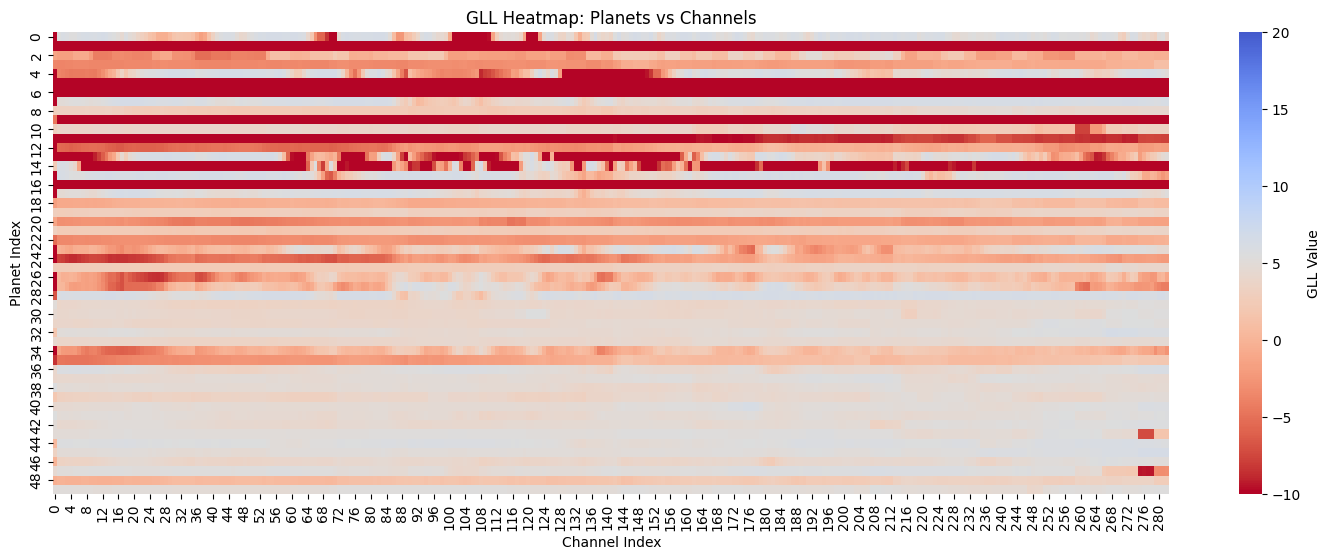

In [45]:
# Create a heatmap of GLL values per planet (row) and channel (column)
import seaborn as sns

# Extract only the gll columns (gll_0, gll_1, ...)
gll_columns = [col for col in df.columns if col.startswith('gll_') and col != 'gll']
heatmap_data = df.sort_values(by='gll')[gll_columns].values
heatmap_data = heatmap_data[:50]
# heatmap_data = heatmap_data.clip(-50, 50)

plt.figure(figsize=(18, 6))
sns.heatmap(heatmap_data, cmap='coolwarm_r', cbar_kws={'label': 'GLL Value'}, vmin=-10, vmax=20, center = 5.5)
plt.xlabel('Channel Index')
plt.ylabel('Planet Index')
plt.title('GLL Heatmap: Planets vs Channels')
plt.show()

In [42]:
df.sort_values(by='gll')[gll_columns].values.mean()

np.float64(5.779944516243172)